#Spiegazione dell'implementazione di un Algoritmo di Face Detection
##Analisi e Sviluppo del Classificatore AdaBoost

### **1. Introduzione**

Facendo una semplice ricerca sulla fece detection si è trovato l'algorito di Viola-jones già discusso nelle lezioni del modulo e utilizzato ad alto livello tramite OpenCV.
Quello che si vuole fare è riprodurre l'algoritmo come descritto negli articoli citati sfruttando scikit-learn per costruire così un modello di face detection da addestrare da zero, rispetto ad avere un modello pre addestrato.
Sebbene l'algoritmo originale di Viola-Jones rappresentasse una soluzione in tempo reale, il presente progetto si focalizza sulla sua architettura semplificata per dimostrare i concetti chiave. Nello specifico, l'implementazione si basa su un singolo stadio di classificazione per combinare le caratteristiche di Haar con il classificatore AdaBoost e una tecnica di non-maximum suppression (NMS) per la post-elaborazione.

### **2. Feature di Haar e Immagine Integrale:la Base per la Classificazione**

Per distinguere un volto da un non-volto, l'algoritmo impiega un insieme di descrizioni numeriche chiamate feature di Haar. Queste feature, ispirate ai concetti di illuminazione e ombra tipici dei volti umani, calcolano la differenza tra la somma dei pixel di diverse aree rettangolari all'interno di una sotto-finestra dell'immagine.

**Implementazione nel Codice**

Il calcolo di un numero così elevato di feature per ogni finestra è reso efficiente dall'utilizzo dell'Immagine Integrale. Questa struttura dati permette di calcolare la somma dei pixel di qualsiasi regione rettangolare in tempo costante, indipendentemente dalla sua dimensione. La libreria scikit-image, utilizzata nella funzione extract_all_haar_features, gestisce in modo efficiente sia il calcolo delle coordinate delle feature sia la generazione dell'immagine integrale. La nostra implementazione si concentra su tre tipi specifici di feature di Haar (type-2-x, type-2-y, type-4), che si sono dimostrati particolarmente efficaci.

**Strategia di Selezione del Dataset**

Per addestrare un classificatore AdaBoost a distinguere i volti dai non-volti, è essenziale un dataset che rifletta la realtà: la stragrande maggioranza delle regioni di un'immagine non contiene un volto. Per questo motivo, il dataset di addestramento è stato costruito con una netta asimmetria: un numero di immagini negative (non-volti) nettamente superiore a quello delle immagini positive (volti), con un rapporto di 3:1. Questo approccio è ispirato all'algoritmo originale di Viola-Jones che consiglia un rapporto di 10:1, non adottato per ovvi motivi di tempo. Questo è cruciale per addestrare il modello a identificare con precisione cosa non è un volto, riducendo significativamente il rischio di falsi positivi.

### **3. Addestramento e Classificazione: il Ruolo di AdaBoost**

L'algoritmo AdaBoost (Adaptive Boosting) è il cuore del nostro classificatore. Il suo scopo è selezionare le feature di Haar più rilevanti e combinarle per creare un modello di previsione accurato. L'implementazione utilizza una singola istanza di AdaBoostClassifier di scikit-learn.

**Differenza dall'Architettura a Cascata Originale**

A differenza del sistema originale di Viola-Jones, che utilizza una cascata di classificatori per ottimizzare l'efficienza computazionale, il presente progetto adotta un approccio a singolo stadio. Nell'algoritmo originale, una serie di classificatori AdaBoost sempre più complessi filtra in sequenza le sotto-finestre di un'immagine, scartando rapidamente i candidati non promettenti.

La scelta di un singolo stadio è stata presa per concentrare lo sforzo implementativo e computazionale sull'addestramento di un unico, robusto classificatore. Questo approccio, pur non replicando l'efficienza in tempo reale della cascata, permette di dimostrare in modo chiaro i principi fondamentali di AdaBoost e delle feature di Haar, mantenendo il progetto gestibile e didatticamente efficace.

**Decisioni di Implementazione**

* Modello base (Weak Learner): Come descritto nel paper originale di Viola-Jones, il modello base (estimator) utilizzato è un albero di decisione molto semplice, un cosiddetto decision stump, con una profondità massima di uno (max_depth=1). Questo garantisce che ogni stadio si concentri su una singola feature di Haar.

* Pipeline e Pre-elaborazione: Per migliorare la stabilità e le prestazioni del modello, abbiamo inserito il classificatore all'interno di una pipeline. Questa pipeline include uno StandardScaler, che normalizza i valori delle feature prima di passarli al classificatore. Questo è cruciale, poiché i valori delle feature di Haar possono variare notevolmente a seconda della dimensione e della posizione, e la standardizzazione evita che le feature con valori più grandi dominino il processo di addestramento.

* Ottimizzazione degli Iperparametri: Per trovare la combinazione ottimale di iperparametri (n_estimators e learning_rate), è stata eseguita una Randomized Search tramite RandomizedSearchCV. Questo approccio esplora in modo efficiente un ampio spazio di parametri, trovando una configurazione che massimizza l'accuratezza del modello sul set di dati.
Si è scelto proprio la RandomizedSearch in quanto tutto il lavoro viene svolto in una macchina a limitate prestazioni e, quindi, serve una tecnica di ottimizzazione che possa essere più veloce possibile ma allo stesso tempo efficace. Utilizzare per esempio una Grid search con pochi parametri scelti avrebbe sicuramente fatto perdere meno tempo, a scapito però della "precisione" nella scelta del giusto iperparametro. La random search non solo è veloce ma permette di essere sicuramente più accurati.

### **4. Rilevamento e Post-Elaborazione**

L'algoritmo esplora l'immagine tramite una finestra scorrevole (sliding window) a più scale, un processo noto come piramide di immagini. A ogni posizione e scala, la sotto-finestra viene analizzata dal classificatore AdaBoost. Poiché un singolo volto può essere rilevato più volte con rettangoli leggermente sovrapposti, una fase di post-elaborazione è indispensabile.

**Implementazione nel Codice**

Il codice gestisce questo problema attraverso la funzione non_max_suppression. Questa tecnica analizza tutti i rettangoli di rilevamento e rimuove quelli che si sovrappongono troppo, mantenendo solo il bounding box più significativo per ogni cluster di rilevamenti. Questo processo è fondamentale per ottenere un output pulito e accurato, come illustrato nel paper di Viola-Jones.

### **5. Conclusioni**

Questa implementazione, pur essendo una versione semplificata dell'algoritmo originale, dimostra i concetti fondamentali di un sistema di rilevamento volti basato su feature e apprendimento automatico.
Per migliorare il modello basterebbe aumentare il numero di weak learner e aumentare ovviamente le immagini di volti e non volti a disposizione, tutto ciò è stato limitato per permettere un'esecuzione dell'algoritmo non troppo lunga.

#Sitografia

- [An Analysis of the Viola-Jones Face Detection Algorithm](https://www.ipol.im/pub/art/2014/104/article.pdf)

- [Rapid Object Detection using a Boosted Cascade of Simple
Features](https://www.cs.cmu.edu/~efros/courses/LBMV07/Papers/viola-cvpr-01.pdf)

- [Computing all the Haar-like features using scikit-image](https://stackoverflow.com/questions/62682760/computing-all-the-haar-like-features-using-scikit-image)

- [AdaBoostClassifier in sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

- [NMS](https://learnopencv.com/non-maximum-suppression-theory-and-implementation-in-pytorch/)

- [caltech faces and non faces (Kaggle)](https://www.kaggle.com/datasets/sagarkarar/caltech-faces-and-non-faces)

- [Pubblicazione di un caso d'uso](https://www.researchgate.net/publication/372398937_Implementation_of_Haar_Cascade_and_Adaboost_Algorithms_in_Photo_Classification_on_Social_Networks)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sagarkarar/caltech-faces-and-non-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'caltech-faces-and-non-faces' dataset.
Path to dataset files: /kaggle/input/caltech-faces-and-non-faces


In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
from skimage.feature import haar_like_feature, haar_like_feature_coord
from skimage.transform import integral_image
import random
import requests
import pickle

# ===============================================================================
# Sezione 1: Configurazione del progetto e caricamento dei dati
# ===============================================================================

FACES_DIR = path+'/caltech/Caltech/PNGImages/faces'
NON_FACES_DIR = path+'/caltech/Caltech/PNGImages/non_faces'

URL_IMAGE_TO_DETECT = "https://github.com/ProfAI/machine-learning-avanzato/blob/main/datasets/face.jpg?raw=true"

FACE_DETECTOR = "face_detector.pkl"

IMAGE_SIZE = (24, 24)

#feature_types = ['type-2-x', 'type-2-y', 'type-3-x', 'type-3-y', 'type-4']
#feature_types = ['type-2-x', 'type-2-y', 'type-3-x', 'type-3-y']
feature_types = ['type-2-x', 'type-2-y', 'type-4']
#feature_types = ['type-2-x', 'type-2-y']


print(f"Il dataset presenta {len(os.listdir(NON_FACES_DIR))} immagini di non volti e {len(os.listdir(FACES_DIR))} di volti")

Assicurati di aver caricato le immagini nelle cartelle:
 - Volti: /kaggle/input/caltech-faces-and-non-faces/caltech/Caltech/PNGImages/faces
 - Non-volti: /kaggle/input/caltech-faces-and-non-faces/caltech/Caltech/PNGImages/non_faces
Trovate 450 immagini di volti.
Selezionate 100 immagini di volti
Trovate 2445 immagini di non-volti.
Selezionate 300 immagini di non-volti per bilanciare il dataset.
Estraendo 107136 caratteristiche di Haar per 400 immagini...
Inizio la ricerca casuale degli iperparametri e l'addestramento...
Ricerca e addestramento completati.

Report di classificazione sul set di test:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        60
           1       0.94      0.85      0.89        20

    accuracy                           0.95        80
   macro avg       0.95      0.92      0.93        80
weighted avg       0.95      0.95      0.95        80


I migliori iperparametri trovati:
{'classifier__learning_rate': np

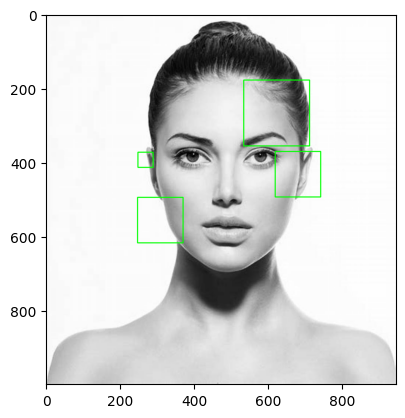

In [ ]:
# ===============================================================================
# Sezione 2: Funzioni di Pre-elaborazione e Feature Engineering
# ===============================================================================

def load_dataset(faces_dir, non_faces_dir, ratio=3):
    """
    Carica le immagini e le etichette.
    Etichetta 1 per i volti, 0 per i non-volti.
    """
    X = []
    y = []

    # Carichiamo le immagini di volti
    face_filenames = os.listdir(faces_dir)
    print(f"Trovate {len(face_filenames)} immagini di volti.")
    if(len(face_filenames) > 100):
        # Selezioniamo un sottoinsieme casuale di volti
        random.shuffle(face_filenames)
        face_filenames = face_filenames[:100]
    print(f"Selezionate {len(face_filenames)} immagini di volti")
    for filename in face_filenames:
        img = cv2.imread(os.path.join(faces_dir, filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = cv2.equalizeHist(img)

            X.append(img)
            y.append(1)

    # Carichiamo le immagini senza volti
    non_face_filenames = os.listdir(non_faces_dir)
    print(f"Trovate {len(non_face_filenames)} immagini di non-volti.")
    if len(non_face_filenames) > len(face_filenames)*ratio:
        # Selezioniamo un sottoinsieme casuale di non-volti
        random.shuffle(non_face_filenames)
        non_face_filenames = non_face_filenames[:len(face_filenames)*ratio]
        print(f"Selezionate {len(non_face_filenames)} immagini di non-volti.")

    for filename in non_face_filenames:
        img = cv2.imread(os.path.join(non_faces_dir, filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = cv2.equalizeHist(img)

            X.append(img)
            y.append(0)

    return np.array(X), np.array(y)

def extract_all_haar_features(image_arr):
    """
    Estrae tutte le possibili caratteristiche di Haar per un array di immagini.
    Questa è la fase di "Feature Engineering" dell'algoritmo.
    """
    # Ottieniamo le coordinate e i tipi di tutte le feature
    coords, types = haar_like_feature_coord(IMAGE_SIZE[0], IMAGE_SIZE[1], feature_type=feature_types)
    all_features_meta = (coords, types)

    # Pre-allochiamo un array per le feature estratte per tutte le immagini
    X_features = np.zeros((image_arr.shape[0], len(coords)))

    print(f"Estraendo {len(coords)} caratteristiche di Haar per {image_arr.shape[0]} immagini...")

    # Iteriamo su ogni immagine per calcolare i valori di tutte le feature
    for i, img in enumerate(image_arr):
        ii = integral_image(img)
        feature_values = haar_like_feature(ii, 0, 0, IMAGE_SIZE[0], IMAGE_SIZE[1], feature_coord=coords, feature_type=types)
        X_features[i, :] = feature_values

    return X_features, all_features_meta


# ===============================================================================
# Sezione 3: Funzione per l'addestramento del modello con Scikit-learn
# ===============================================================================

def train_face_detector(X_features, y_labels):
    """
    Addestra un classificatore AdaBoost sui dati con le caratteristiche di Haar,
    utilizzando una pipeline e ottimizzando gli iperparametri.
    """
    # Suddividiamo i dati in training e test set
    X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, stratify=y_labels, random_state=42)

    # Creiamo una semplice pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), random_state=42))
    ])

    # Definiamo la distribuzione degli iperparametri per la ricerca casuale
    param_distributions = {
        'classifier__n_estimators': randint(20, 70),
        'classifier__learning_rate': uniform(0.1, 1.0)
    }

    # Configuriamo la RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=4,
        cv=3,
        n_jobs=-1,
        random_state=42
    )

    print("Inizio la ricerca casuale degli iperparametri e l'addestramento...")
    random_search.fit(X_train, y_train)
    print("Ricerca e addestramento completati.")

    # Valutiamo il miglior modello
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)

    print("\nReport di classificazione sul set di test:")
    print(classification_report(y_test, y_pred))

    print("\nI migliori iperparametri trovati:")
    print(random_search.best_params_)

    return best_model


# ===============================================================================
# Sezione 4: Funzioni per il rilevamento dei volti in una nuova immagine
# ===============================================================================

def detect_faces(model, image, all_features_meta):
    """
    Rileva i volti in un'immagine usando una finestra scorrevole a più scale e
    applica NMS per eliminare le sovrapposizioni.
    """
    if image is None:
        print("Errore: Immagine non valida.")
        return []

    coords, types = all_features_meta
    detected_faces_coords = []

    # Parametri per la piramide di immagini e NMS
    scale_factor = 1.2
    min_size = (30, 30)

    current_image = image.copy()
    current_scale = 1.0

    print("Inizio la scansione dell'immagine a più scale...")

    # Piramide di immagini: ridimensiona l'immagine per trovare volti di diverse dimensioni.
    while min(current_image.shape[:2]) > max(min_size):
        step = 24
        window_w, window_h = IMAGE_SIZE

        # Implementiamo la logica di rilevamento (sliding window)
        for y in range(0, current_image.shape[0] - window_h, step):
            for x in range(0, current_image.shape[1] - window_w, step):
                sub_image = current_image[y:y+window_h, x:x+window_w]

                # Calcolo dell'immagine integrale per la sub_image
                ii = integral_image(sub_image)

                # Estrazione delle caratteristiche di Haar
                feature_values = haar_like_feature(ii, 0, 0, window_w, window_h, feature_coord=coords, feature_type=types)
                feature_values = feature_values.reshape(1, -1)

                # Predizione del modello
                prediction = model.predict(feature_values)

                # Se la predizione è '1', è stato trovato un volto
                if prediction == 1:
                    # Calcola le coordinate del rettangolo sull'immagine originale
                    orig_x = int(x * current_scale)
                    orig_y = int(y * current_scale)
                    orig_w = int(window_w * current_scale)
                    orig_h = int(window_h * current_scale)
                    detected_faces_coords.append((orig_x, orig_y, orig_w, orig_h))

        # Ridimensioniamo l'immagine per la prossima iterazione
        current_image = cv2.resize(current_image, (int(current_image.shape[1] / scale_factor), int(current_image.shape[0] / scale_factor)))
        current_scale *= scale_factor

    print("Sliding Window completata, inizio NMS (Soppressione dei Non-massimi)")

    # Applichiamo la NMS (Soppressione dei Non-massimi) per eliminare i rettangoli sovrapposti
    rects = np.array(detected_faces_coords)
    if len(rects) > 0:
        indices = non_max_suppression(rects, overlapThresh=0.3)
        detected_faces_coords = [detected_faces_coords[i] for i in indices]

    if not detected_faces_coords:
        print("Nessun volto rilevato.")
        return []

    print(f"Trovati {len(detected_faces_coords)} volti dopo NMS.")
    return detected_faces_coords

def non_max_suppression(boxes, overlapThresh):
    """
    Applica la soppressione dei non-massimi.
    Prende una lista di bounding box e una soglia di sovrapposizione.
    Restituisce gli indici dei bounding box da mantenere.
    """

    # Ritorniamo una lista vuota se non ci sono bounding box.
    if len(boxes) == 0:
        return []

    # Converte i bounding box in float se sono interi per evitare errori di divisione.
    if boxes.dtype.kind == "i":
        boxes = boxes.astype("float")

    keep = []

    # Estraimo le coordinate dei bounding box.
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    # Calcoliamo l'area di ogni bounding box.
    area = (x2 - x1 + 1) * (y2 - y1 + 1)
    # Ordina gli indici in base alla coordinata y del rettangolo per un'elaborazione coerente.
    idxs = np.argsort(y2)

    # Inizia il ciclo finché ci sono indici da esaminare.
    while len(idxs) > 0:

        # Prende l'ultimo indice, che corrisponde al rettangolo con la y più alta.
        last = len(idxs) - 1
        i = idxs[last]
        keep.append(i)

        # Calcola le coordinate del rettangolo di intersezione.
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        # Calcola la larghezza e l'altezza dell'intersezione.
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Calcola il rapporto di sovrapposizione.
        overlap = (w * h) / area[idxs[:last]]

        # Elimina tutti gli indici che hanno un'alta sovrapposizione.
        idxs = np.delete(idxs, np.concatenate(([last], np.where(overlap > overlapThresh)[0])))

    # Ritorniamo gli indici
    return keep

def draw_rectangle(image, faces_coords):
    """
    Disegna rettangoli sull'immagine per ogni volto rilevato e mostra l'immagine.
    """
    if image is None:
        return

    # Convertiamo l'immagine da scala di grigi a colori per disegnare il rettangolo
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    for (x, y, w, h) in faces_coords:
        # Disegna un rettangolo verde (colore RGB: 0, 255, 0)
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.imshow(image)

def read_image_from_url(url, gray=True):
    """
    Scarica un'immagine da un URL e la converte in un array OpenCV.
    """
    try:
        # Scarichiamo l'immagine dal web
        resp = requests.get(url, stream=True).raw
        img = np.asarray(bytearray(resp.read()), dtype="uint8")

        # Usiamo cv2.imdecode per leggere l'immagine dall'array
        if(gray==True):
            img = cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)

        return img
    except Exception as e:
        print(f"Errore durante il download o la decodifica dell'immagine: {e}")
        return None


# ===============================================================================
# Sezione 5: Funzioni per salvare il modello e renderlo riutilizzabile
# ===============================================================================

def save_model(model, filename):
    """
    Salva il modello addestrato su disco.
    """
    if model is None:
        raise Exception("Il modello non è stato addestrato. Non è possibile salvarlo.")
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"Modello salvato su '{filename}'")

def load_model(filename):
    """
    Carica un modello addestrato da un file.
    """
    with open(filename, 'rb') as f:
        model = pickle.load(f)
    print(f"Modello caricato da '{filename}'")
    return model


# ===============================================================================
# Sezione 6: Funzione Main
# ===============================================================================

if __name__ == '__main__':

    #Creiamo le cartelle se non esistono
    os.makedirs(FACES_DIR, exist_ok=True)
    os.makedirs(NON_FACES_DIR, exist_ok=True)

    print("Assicurati di aver caricato le immagini nelle cartelle:")
    print(f" - Volti: {FACES_DIR}")
    print(f" - Non-volti: {NON_FACES_DIR}")

    # Carichiamo e pre-elaboriamo i dati
    X_data, y_labels = load_dataset(FACES_DIR, NON_FACES_DIR)

    if len(X_data) > 0:
        # Estraiamo le feature da tutto il dataset
        X_features, all_haar_features_meta = extract_all_haar_features(X_data)

        # Addestriamo il modello
        face_detector_model = train_face_detector(X_features, y_labels)

        # Salviamo il modello
        save_model(face_detector_model, FACE_DETECTOR)

        # Carichiamo il modello
        model = load_model(FACE_DETECTOR)

        # Scarichiamo e analizziamo l'immagine
        print("\nAnalisi dell'immagine da URL...")
        image_to_detect = read_image_from_url(URL_IMAGE_TO_DETECT)
        detected_faces = detect_faces(model, image_to_detect, all_haar_features_meta)
        print(f"Coordinate dei volti rilevati: {detected_faces}")
        # Disegna i rettangoli sull'immagine e salvala
        draw_rectangle(image_to_detect, detected_faces)
        plt.show()
    else:
        print("\nDataset vuoto. Carica le immagini per procedere.")